In [43]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml.biomarcers.config import Config
from ml.biomarcers.model_transunet import TransUNet

%matplotlib inline

### Загрузка модели TransUNet

- **Архитектура:** TransUNet (гибрид Transformer + U-Net)
- **Размер входа:** 512×512 пикселей
- **Количество классов:** 15 (14 патологий + фон)
- **Устройство:** CPU
- **Чекпоинт:** лучшая модель по валидационному Dice

In [44]:
config = Config()
DEVICE = torch.device("cpu")
MODEL_PATH = "/Users/mamaevalex/aspirantura/PROF/models/best_model.pth"

model = TransUNet(
    img_dim=config.PATCH_SIZE,
    num_classes=config.NUM_CLASSES
).to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Epoch: {checkpoint.get('epoch', 'unknown')}, val_dice: {checkpoint.get('val_dice', 'unknown')}")
else:
    model.load_state_dict(checkpoint)

model.eval()
print("Model loaded on CPU")

Epoch: 5, val_dice: 0.10151899936832566
Model loaded on CPU


### Маппинг классов

Разворачиваем словарь `CLASS_TO_ID` (имя → номер) в обратный `ID_TO_CLASS` (номер → имя).
Добавляем класс `0` как `background`. Всего 15 классов.

In [54]:
CLASS_TO_ID = config.CLASS_TO_ID
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
ID_TO_CLASS[0] = "background"
NUM_CLASSES = len(ID_TO_CLASS)
print(f"Classes: {ID_TO_CLASS}")

Classes: {1: 'drusen', 2: 'edema', 3: 'epiretinal_fibrosis', 4: 'fibrosis', 5: 'geographic_atrophy', 6: 'hard_exudates', 7: 'hemorrhages', 8: 'laser_coagulates', 9: 'macular_hole', 10: 'microaneurysms', 11: 'neovascularization', 12: 'soft_exudates', 13: 'subretinal_hemorrhage', 14: 'venous_anomalies', 0: 'background'}


### Функция визуализации `visualize_prediction`

Отображает результаты предсказания модели на одном снимке в виде сетки 2×3:

**Верхний ряд:**
| Оригинал | Ground Truth (наложение) | Prediction (наложение) |
|----------|--------------------------|------------------------|

**Нижний ряд:**
| Текстовый отчёт | Ground Truth (чистая маска) | Prediction (чистая маска) |
|-----------------|-----------------------------|---------------------------|

**Текстовый отчёт содержит:**
- Количество классов в GT и предсказании
- `[FOUND]` — классы, совпавшие с GT (с числом пикселей)
- `[MISSED]` — классы из GT, не найденные моделью
- `[FALSE POS]` — классы, предсказанные ошибочно

Каждый класс раскрашен фиксированным цветом. При передаче `save_path` картинка сохраняется на диск.

In [74]:
def visualize_prediction(image, gt_mask, pred_mask, id_to_class, save_path=None):
    CLASS_COLORS = {
        1:  [1.0, 0.0, 0.0],
        2:  [0.0, 1.0, 0.0],
        3:  [0.0, 0.0, 1.0],
        4:  [1.0, 1.0, 0.0],
        5:  [1.0, 0.0, 1.0],
        6:  [0.0, 1.0, 1.0],
        7:  [0.5, 0.5, 0.5],
        8:  [1.0, 0.5, 0.0],
        9:  [0.5, 0.0, 0.5],
        10: [0.0, 0.5, 0.0],
        11: [0.5, 0.0, 0.0],
        12: [0.0, 0.0, 0.5],
        13: [0.5, 0.5, 0.0],
        14: [0.0, 0.5, 0.5],
    }

    def colorize(mask):
        colored = np.zeros((*mask.shape, 3))
        for cls in np.unique(mask):
            if cls != 0:
                colored[mask == cls] = CLASS_COLORS.get(cls, [1, 1, 1])
        return colored

    fig = plt.figure(figsize=(22, 12))

    # === Верхний ряд ===
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(image)
    ax1.set_title("Original Image", fontsize=14, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.imshow(image)
    ax2.imshow(colorize(gt_mask), alpha=0.5)
    ax2.set_title("Ground Truth (overlay)", fontsize=14, fontweight='bold')
    ax2.axis('off')

    ax3 = fig.add_subplot(2, 3, 3)
    ax3.imshow(image)
    ax3.imshow(colorize(pred_mask), alpha=0.5)
    ax3.set_title("Prediction (overlay)", fontsize=14, fontweight='bold')
    ax3.axis('off')

    # === Нижний ряд ===
    ax4 = fig.add_subplot(2, 3, 5)
    ax4.imshow(colorize(gt_mask))
    ax4.set_title("Ground Truth Mask", fontsize=14, fontweight='bold')
    ax4.axis('off')

    ax5 = fig.add_subplot(2, 3, 6)
    ax5.imshow(colorize(pred_mask))
    ax5.set_title("Predicted Mask", fontsize=14, fontweight='bold')
    ax5.axis('off')

    # === Описание слева внизу ===
    ax_desc = fig.add_subplot(2, 3, 4)
    ax_desc.axis('off')
    ax_desc.set_xlim(0, 10)
    ax_desc.set_ylim(0, 10)

    gt_classes = set(np.unique(gt_mask)) - {0}
    pred_classes = set(np.unique(pred_mask)) - {0}
    found = gt_classes & pred_classes
    missed = gt_classes - pred_classes
    extra = pred_classes - gt_classes

    lines = []
    lines.append(f"GT classes: {len(gt_classes)}  |  Pred classes: {len(pred_classes)}")
    lines.append("")

    if found:
        lines.append(f"[FOUND] ({len(found)}):")
        for cls in sorted(found):
            gt_px = (gt_mask == cls).sum()
            pred_px = (pred_mask == cls).sum()
            lines.append(f"  - {id_to_class.get(cls, cls)}")
            lines.append(f"    GT: {gt_px} px  |  Pred: {pred_px} px")
    else:
        lines.append("[FOUND]: none")

    lines.append("")

    if missed:
        lines.append(f"[MISSED] ({len(missed)}):")
        for cls in sorted(missed):
            lines.append(f"  - {id_to_class.get(cls, cls)}")
    else:
        lines.append("[MISSED]: none")

    lines.append("")

    if extra:
        lines.append(f"[FALSE POS] ({len(extra)}):")
        for cls in sorted(extra):
            lines.append(f"  - {id_to_class.get(cls, cls)}")
    else:
        lines.append("[FALSE POS]: none")

    text = "\n".join(lines)
    ax_desc.text(2.0, 9.5, text, fontsize=18, verticalalignment='top',
                 fontfamily='monospace', color='black',
                 bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.9, pad=0.8))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

### Загрузка тестовых данных

Читаем CSV с путями к снимкам и маскам (`image` и `mask`), а также метаинформацией о классах и фолдах.

In [56]:
TEST_CSV = "/Users/mamaevalex/aspirantura/PROF/npy_article_fold/train_article_fold_1.csv"
df = pd.read_csv(TEST_CSV)

print(f"Total samples: {len(df)}")

df.head()

Total samples: 1718


,image,mask,width,height,mask_width,mask_height,ERROR,OD,background,drusen,...,hard_exudates,hemorrhages,laser_coagulates,macular_hole,microaneurysms,neovascularization,soft_exudates,subretinal_hemorrhage,venous_anomalies,fold
0,D:\aspirantura\PROF\npy_article_fold\fold_1\im...,D:\aspirantura\PROF\npy_article_fold\fold_1\ma...,1956,1934,1956,1934,0.0,0,0.999239,1,...,1,1,0,0,0,0,0,0,0,0
1,D:\aspirantura\PROF\npy_article_fold\fold_1\im...,D:\aspirantura\PROF\npy_article_fold\fold_1\ma...,1956,1934,1956,1934,0.0,0,0.999239,1,...,1,1,0,0,0,0,0,0,0,0
2,D:\aspirantura\PROF\npy_article_fold\fold_1\im...,D:\aspirantura\PROF\npy_article_fold\fold_1\ma...,1956,1934,1956,1934,0.0,0,0.999239,1,...,1,1,0,0,0,0,0,0,0,0
3,D:\aspirantura\PROF\npy_article_fold\fold_1\im...,D:\aspirantura\PROF\npy_article_fold\fold_1\ma...,1956,1934,1956,1934,0.0,0,0.998484,0,...,0,0,0,0,1,0,0,0,0,0
4,D:\aspirantura\PROF\npy_article_fold\fold_1\im...,D:\aspirantura\PROF\npy_article_fold\fold_1\ma...,1956,1934,1956,1934,0.0,0,0.998484,0,...,0,0,0,0,1,0,0,0,0,0


### Выбор снимка для визуализации

По индексу `sample_idx` извлекаем строку датафрейма.
Из полных путей выделяем только имена файлов для загрузки из локальных папок.

In [79]:
sample_idx = 0
row = df.iloc[sample_idx]

img_name = row['image'].split('\\')[-1]
mask_name = row['mask'].split('\\')[-1]

print(f"Image: {img_name}")
print(f"Mask: {mask_name}")

Image: 007-1789-100_512_512.npy
Mask: 007-1789-100_512_512.npy


### Загрузка и препроцессинг снимка

Загружаем `.npy` файлы изображения и маски из папок фолда.
Препроцессинг полностью повторяет `ImageMaskDataset`:

1. Нормализация в `[0, 1]`
2. ImageNet-стандартизация (mean/std)
3. Преобразование в тензор `(1, 3, 512, 512)` и `(1, 512, 512)`

In [59]:
IMAGE_DIR = "/Users/mamaevalex/aspirantura/PROF/npy_article_fold/fold_1/images"
MASK_DIR = "/Users/mamaevalex/aspirantura/PROF/npy_article_fold/fold_1/masks"

# Загружаем
image = np.load(os.path.join(IMAGE_DIR, img_name))
gt_mask = np.load(os.path.join(MASK_DIR, mask_name))

# Нормализация как в ImageMaskDataset
img = image.astype(np.float32) / 255.0
for i, m in enumerate(config.IMAGENET_MEAN):
    img[..., i] = (img[..., i] - m) / config.IMAGENET_STD[i]

image_tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0)
mask_tensor = torch.from_numpy(gt_mask).long().unsqueeze(0)

print(f"Image tensor: {image_tensor.shape}, dtype: {image_tensor.dtype}")
print(f"Mask tensor: {mask_tensor.shape}, unique: {torch.unique(mask_tensor)}")

Image tensor: torch.Size([1, 3, 512, 512]), dtype: torch.float32
Mask tensor: torch.Size([1, 512, 512]), unique: tensor([0, 1, 7])


### Предсказание модели

Прогоняем изображение через TransUNet на CPU в `eval` режиме:

1. Получаем логиты и берём `argmax` — предсказанная маска
2. При необходимости интерполируем к размеру исходной маски
3. Денормализуем изображение (обратно из ImageNet) для визуализации

На выходе: `pred_mask` — предсказание, `gt_mask` — разметка, `img_vis` — оригинал в [0,1].

In [60]:
image_tensor = image_tensor.to(DEVICE)

with torch.no_grad():
    logits = model(image_tensor)

# Интерполяция если нужно (как в оригинальном test_model)
if logits.shape[-2:] != mask_tensor.shape[-2:]:
    logits = F.interpolate(logits, size=mask_tensor.shape[-2:], mode="bilinear", align_corners=False)

pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()  # (H, W)
gt_mask = mask_tensor.squeeze().cpu().numpy()

# Оригинальное изображение для отображения (из тензора обратно)
image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()

# Денормализация ImageNet для визуализации
img_vis = image_np.copy()
for i, (m, s) in enumerate(zip(config.IMAGENET_MEAN, config.IMAGENET_STD)):
    img_vis[..., i] = img_vis[..., i] * s + m
img_vis = np.clip(img_vis, 0, 1)

print(f"Pred mask unique classes: {np.unique(pred_mask)}")
print(f"GT mask unique classes: {np.unique(gt_mask)}")

Pred mask unique classes: [0 7]
GT mask unique classes: [0 1 7]


### Визуализация результата

Вызываем `visualize_prediction` — отображается сетка из 5 изображений и текстовый отчёт с анализом найденных, пропущенных и ложных классов.

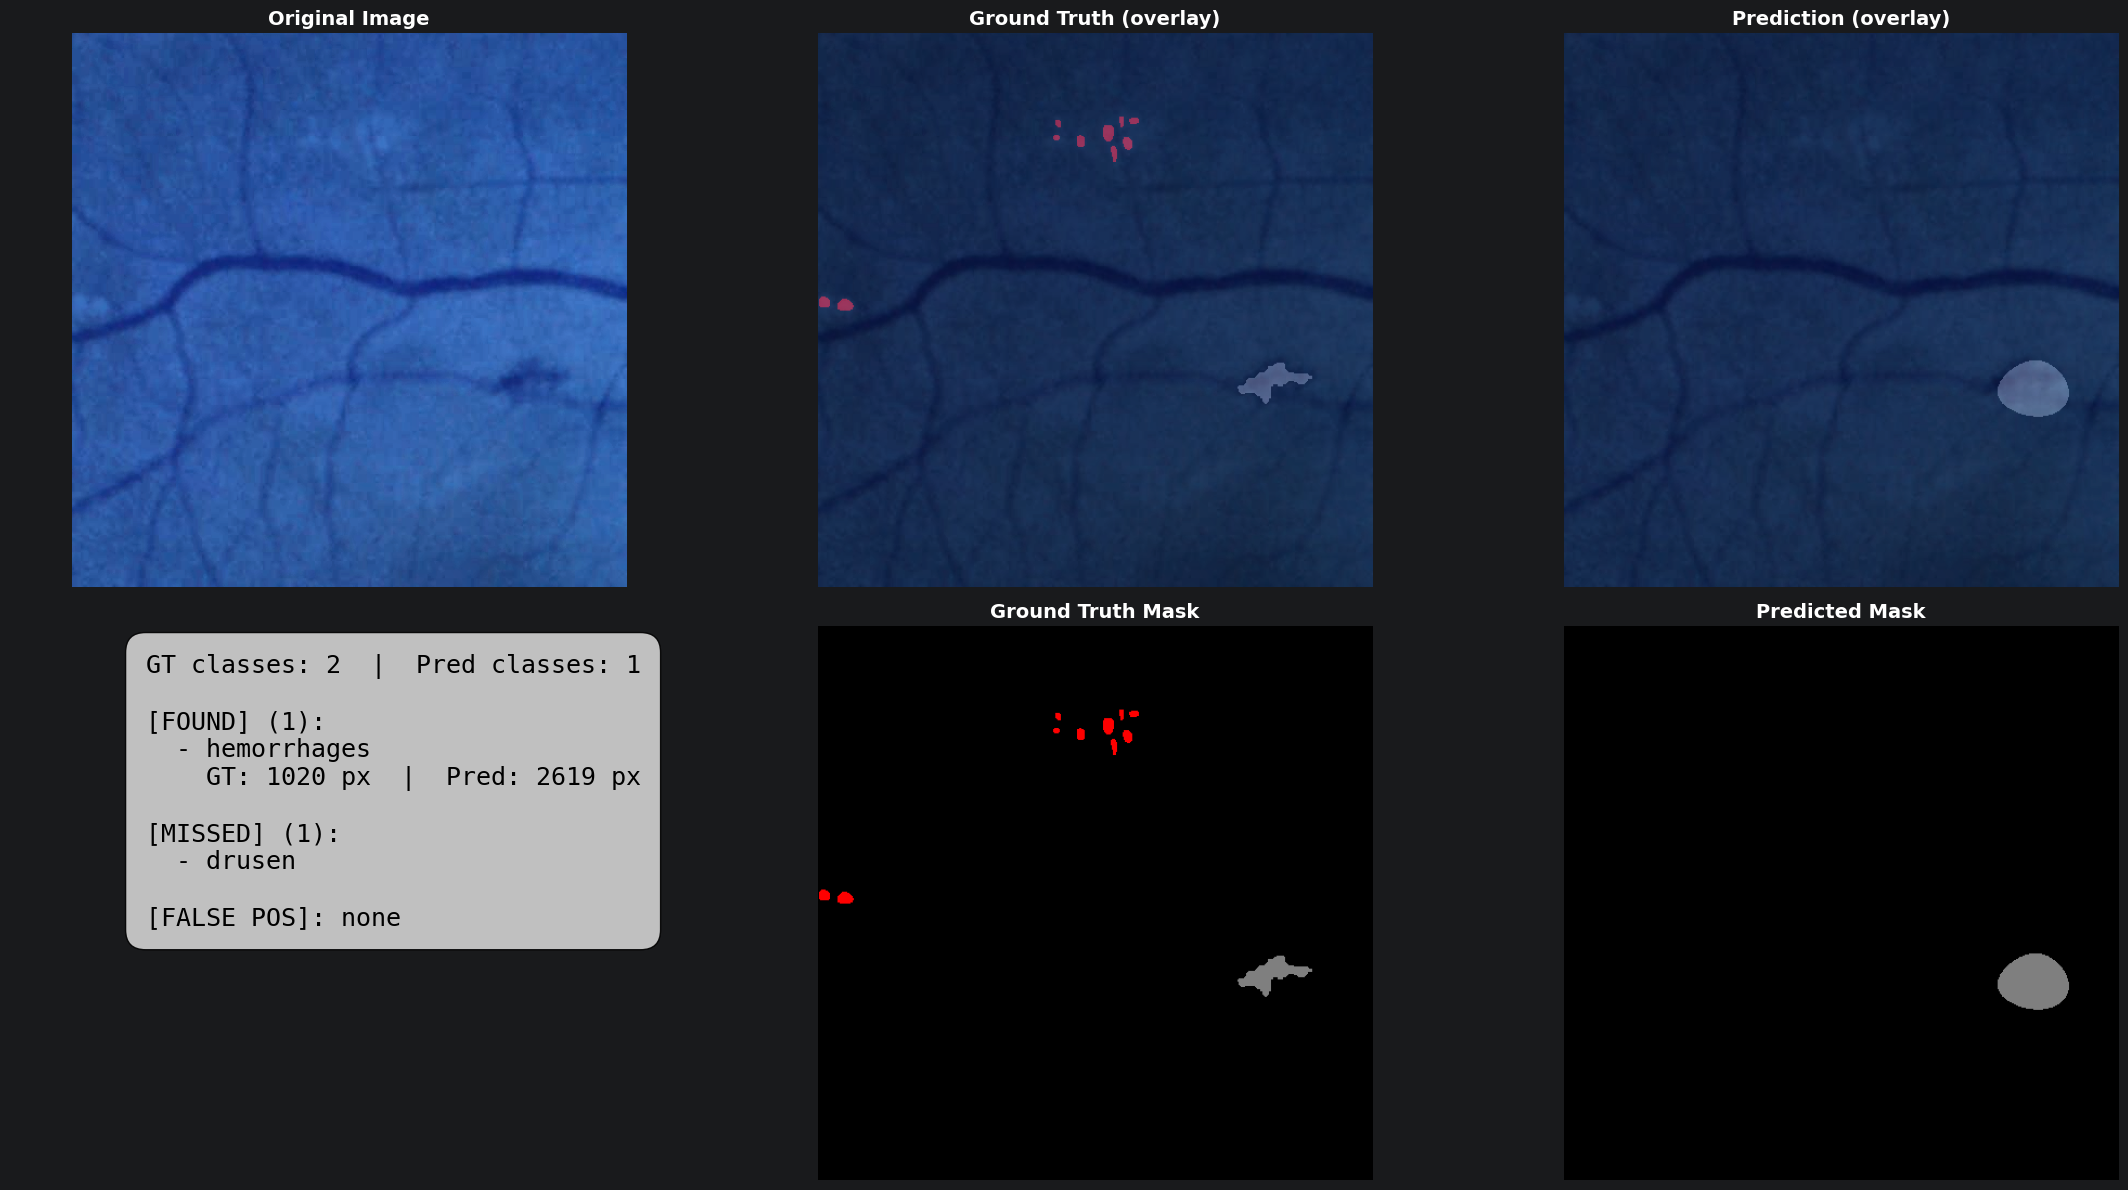

In [75]:
visualize_prediction(img_vis, gt_mask, pred_mask, ID_TO_CLASS)